In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
rng = np.random.default_rng(2021)
N = 300

In [3]:
# ----------------------------------------------------------------------------
# BUILD covid_data.csv
# ----------------------------------------------------------------------------
age = np.clip(rng.normal(54, 9, N).round().astype(int), 29, 77)
sex = rng.choice(["Male", "Female"], size=N, p=[0.68, 0.32])      # heart data skews male
cp = rng.integers(0, 4, N)                                        # criticality 0..3
trtbps = np.clip(rng.normal(131, 17, N).round().astype(int), 94, 200)
chol = np.clip(rng.normal(246, 51, N).round().astype(int), 126, 564)
fbs = rng.choice([0, 1], size=N, p=[0.85, 0.15])                  # fasting sugar >120
restecg = rng.choice([0, 1, 2], size=N, p=[0.49, 0.49, 0.02])
# thalachh (max heart rate) falls with age -> clear negative relationship
thalachh = np.clip((210 - 0.9 * age + rng.normal(0, 15, N)).round().astype(int), 71, 202)

# NOTE: avoid the literal string "None" - pandas read_csv reads it back as NaN
addiction = rng.choice(["No-Addiction", "Alcohol", "Nicotine", "Drug", "Alcohol+Nicotine", "Other"],
                       size=N, p=[0.40, 0.18, 0.20, 0.07, 0.10, 0.05])
keratin_type = rng.choice(["Alpha", "Beta", "Gamma"], size=N, p=[0.5, 0.35, 0.15])
diabetes = rng.choice(["Non-Diabetic", "Type 2", "Type 1", "Prediabetic"],
                      size=N, p=[0.45, 0.30, 0.12, 0.13])
# Hemoglobin: males a bit higher; some patients anaemic (<10), both sexes represented
hb = np.where(sex == "Male", rng.normal(14.2, 2.2, N), rng.normal(12.5, 2.0, N))
hb = np.clip(hb, 7.0, 18.5).round(1)
blood_grp = rng.choice(["O+", "A+", "B+", "AB+", "O-", "A-", "B-", "AB-"],
                       size=N, p=[0.34, 0.28, 0.18, 0.07, 0.05, 0.04, 0.03, 0.01])
immunity = rng.choice([1, 2, 3], size=N, p=[0.3, 0.45, 0.25])     # 1 = highest
lungs = np.clip(rng.normal(35, 18, N), 0, 95).round(1)
breath = np.clip(rng.normal(1.1, 0.35, N), 0.4, 2.2).round(2)

# Survival depends on diabetes type, age and lung damage -> meaningful crosstab
base_surv = {"Non-Diabetic": 0.86, "Prediabetic": 0.76, "Type 2": 0.62, "Type 1": 0.55}
p_surv = np.array([base_surv[d] for d in diabetes])
p_surv = p_surv - (age - 54) * 0.004 - (lungs - 35) * 0.004      # older / worse lungs -> lower
p_surv = np.clip(p_surv, 0.05, 0.97)
survive = np.where(rng.random(N) < p_surv, "Survived", "Passed Away")

df = pd.DataFrame({
    "pid": [f"P{1000 + i}" for i in range(N)],
    "Age": age, "Sex": sex, "cp": cp, "trtbps": trtbps, "chol": chol,
    "fbs": fbs, "restecg": restecg, "thalachh": thalachh,
    "Addiction": addiction, "keratin_type": keratin_type,
    "Diabetestype": diabetes, "Hemoglobin": hb, "blood_grp": blood_grp,
    "Immunity": immunity, "Affected_portion_lungs": lungs,
    "Breath_ratio": breath, "Survive_status": survive,
})
print("covid_data.csv built:", df.shape)
print(df.head(4).to_string(index=False))



covid_data.csv built: (300, 18)
  pid  Age  Sex  cp  trtbps  chol  fbs  restecg  thalachh    Addiction keratin_type Diabetestype  Hemoglobin blood_grp  Immunity  Affected_portion_lungs  Breath_ratio Survive_status
P1000   53 Male   3     154   228    1        0       170 No-Addiction         Beta       Type 1        13.6        O+         3                    27.3          0.91       Survived
P1001   48 Male   3     149   275    0        0       147         Drug        Alpha       Type 2        14.9        A+         2                    50.0          1.29       Survived
P1002   47 Male   3     123   352    0        0       180 No-Addiction        Alpha       Type 2        18.5        A+         2                    28.0          0.77       Survived
P1003   64 Male   2     131   320    0        1       141        Other        Alpha       Type 2        18.1       AB+         2                    22.4          1.11    Passed Away


In [6]:
# ============================================================================
print("\n" + "=" * 70)
print("QUESTION 4a  -  COVID DATASET")
print("=" * 70)

df = pd.read_csv("covid_data.csv")
df.head()


QUESTION 4a  -  COVID DATASET


,pid,Age,Sex,cp,trtbps,chol,fbs,restecg,thalachh,Addiction,keratin_type,Diabetestype,Hemoglobin,blood_grp,Immunity,Affected_portion_lungs,Breath_ratio,Survive_status
0,P1000,53,Male,3,154,228,1,0,170,No-Addiction,Beta,Type 1,13.6,O+,3,27.3,0.91,Survived
1,P1001,48,Male,3,149,275,0,0,147,Drug,Alpha,Type 2,14.9,A+,2,50.0,1.29,Survived
2,P1002,47,Male,3,123,352,0,0,180,No-Addiction,Alpha,Type 2,18.5,A+,2,28.0,0.77,Survived
3,P1003,64,Male,2,131,320,0,1,141,Other,Alpha,Type 2,18.1,AB+,2,22.4,1.11,Passed Away
4,P1004,54,Male,0,127,358,0,1,147,Alcohol,Beta,Non-Diabetic,17.0,A+,2,22.2,1.08,Passed Away


In [7]:
# ---- 4a.1  convert selected columns to categorical -------------------------
cat_cols = ["cp", "fbs", "restecg", "keratin_type", "Immunity"]
print("\n[1] dtypes BEFORE conversion:")
print(df[cat_cols].dtypes.to_string())
for col in cat_cols:                                  # convert each to 'category'
    df[col] = df[col].astype("category")
print("\n    dtypes AFTER conversion:")
print(df[cat_cols].dtypes.to_string())


[1] dtypes BEFORE conversion:
cp               int64
fbs              int64
restecg          int64
keratin_type    object
Immunity         int64

    dtypes AFTER conversion:
cp              category
fbs             category
restecg         category
keratin_type    category
Immunity        category


In [8]:
# ---- 4a.2  drop the patient id column --------------------------------------
print("\n[2] columns before drop:", len(df.columns))
df = df.drop(columns=["pid"])                          # remove 'pid'
print("    columns after drop :", len(df.columns), "(pid removed)")



[2] columns before drop: 18
    columns after drop : 17 (pid removed)


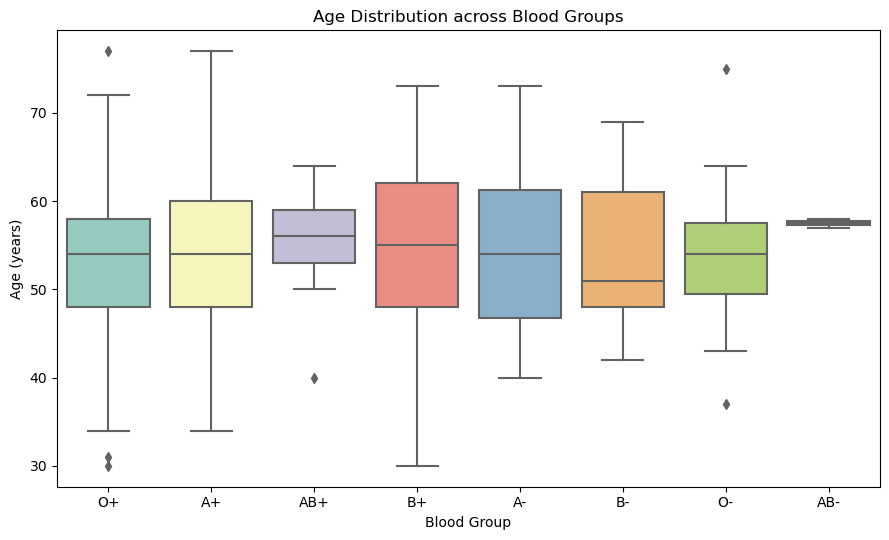


[3] Median Age by blood group:
blood_grp
A+     54.0
A-     54.0
AB+    56.0
AB-    57.5
B+     55.0
B-     51.0
O+     54.0
O-     54.0


In [9]:
# ---- 4a.3 Age distribution over blood_grp (boxplot) ----------------------

plt.figure(figsize=(9, 5.5))

sns.boxplot(
    data=df,
    x="blood_grp",
    y="Age",
    palette="Set3"
)

plt.title("Age Distribution across Blood Groups")
plt.xlabel("Blood Group")
plt.ylabel("Age (years)")

plt.tight_layout()
plt.show()

print("\n[3] Median Age by blood group:")
print(df.groupby("blood_grp")["Age"].median().to_string())

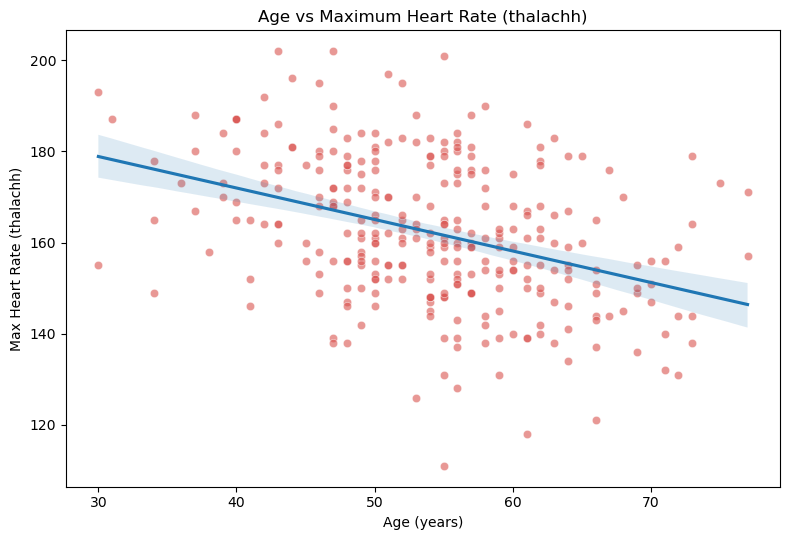


[4] Age-thalachh correlation: -0.383


In [10]:
# ---- 4a.4 relationship between Age & thalachh (scatter) ------------------

plt.figure(figsize=(8, 5.5))

sns.scatterplot(
    data=df,
    x="Age",
    y="thalachh",
    color="#d9534f",
    alpha=0.6
)

sns.regplot(
    data=df,
    x="Age",
    y="thalachh",
    scatter=False,
    color="#1f77b4"
)

plt.title("Age vs Maximum Heart Rate (thalachh)")
plt.xlabel("Age (years)")
plt.ylabel("Max Heart Rate (thalachh)")

plt.tight_layout()
plt.show()

print("\n[4] Age-thalachh correlation:",
      round(df["Age"].corr(df["thalachh"]), 3))

In [11]:
# ---- 4a.5  unique addiction values + how many ------------------------------
uniq = df["Addiction"].unique()
print("\n[5] Unique Addiction values:", list(uniq))
print("    Number of addiction types:", df["Addiction"].nunique())



[5] Unique Addiction values: ['No-Addiction', 'Drug', 'Other', 'Alcohol', 'Alcohol+Nicotine', 'Nicotine']
    Number of addiction types: 6


In [12]:

# ============================================================================
print("\n" + "=" * 70)
print("QUESTION 4b  -  COVID DATASET")
print("=" * 70)

# ---- 4b.1  crosstab Diabetes type x survival + survival % ------------------
ct = pd.crosstab(df["Diabetestype"], df["Survive_status"])     # counts table
ct["Total"] = ct.sum(axis=1)
ct["Survival %"] = (ct["Survived"] / ct["Total"] * 100).round(2)
print("\n[1] Diabetes type vs survival (with survival %):")
print(ct.to_string())



QUESTION 4b  -  COVID DATASET

[1] Diabetes type vs survival (with survival %):
Survive_status  Passed Away  Survived  Total  Survival %
Diabetestype                                            
Non-Diabetic             21       109    130       83.85
Prediabetic              12        30     42       71.43
Type 1                   12        17     29       58.62
Type 2                   34        65     99       65.66


In [13]:
# ---- 4b.2  avg Hemoglobin by sex + count with Hb < 10 ----------------------
print("\n[2] Average Hemoglobin by sex:")
print(df.groupby("Sex")["Hemoglobin"].mean().round(2).to_string())
low_hb = df[df["Hemoglobin"] < 10]
print("    Patients with Hemoglobin < 10, by sex:")
print(low_hb.groupby("Sex").size().reindex(["Female", "Male"], fill_value=0).to_string())


[2] Average Hemoglobin by sex:
Sex
Female    12.75
Male      14.40
    Patients with Hemoglobin < 10, by sex:
Sex
Female    12
Male       2


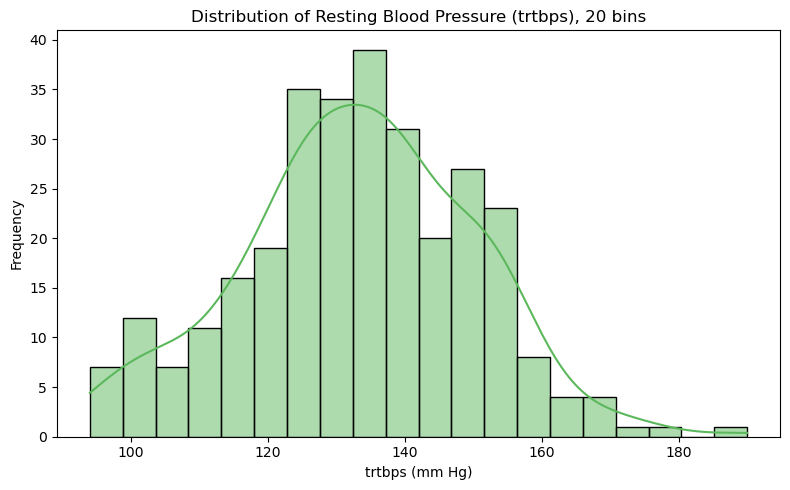

In [14]:
# ---- 4b.3 distribution of trtbps (20 bins) --------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    df["trtbps"],
    bins=20,
    kde=True,
    color="#5cb85c"
)

plt.title("Distribution of Resting Blood Pressure (trtbps), 20 bins")
plt.xlabel("trtbps (mm Hg)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

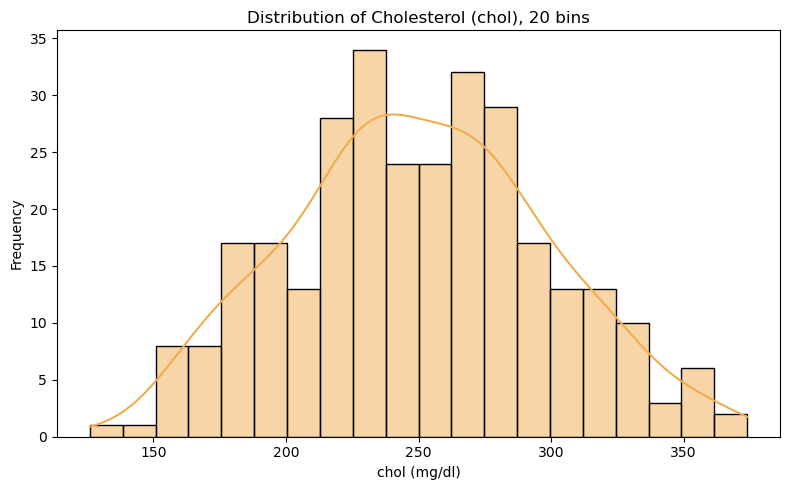


[3][4] chol summary:
count    300.0
mean     249.9
std       48.3
min      126.0
25%      217.0
50%      249.0
75%      282.2
max      374.0


In [15]:
# ---- 4b.4 distribution of chol (20 bins) ----------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    df["chol"],
    bins=20,
    kde=True,
    color="#f0ad4e"
)

plt.title("Distribution of Cholesterol (chol), 20 bins")
plt.xlabel("chol (mg/dl)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print("\n[3][4] chol summary:")
print(df["chol"].describe().round(1).to_string())